### Carga de datos
---

In [110]:
import pandas as pd
import matplotlib.pyplot as plt

In [111]:
df = pd.read_parquet("./datos/02-processed/tarjetas_limpias.parquet")

# Repara las columnas de texto
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].apply(lambda x: x.encode("latin1").decode("utf-8") if isinstance(x, str) else x)

In [112]:
df.sample(2)

,TIPOENTIDAD,CODIGOENTIDAD,NOMBREENTIDAD,FECHACORTE,COD_UCA,NOMBRE_UCA,SUBCUENTA,DESCRIPCION,PERSONA_NATURAL,PERSONA_JURIDICA,TOTAL_TARJETAS,AÑO,MES,MES_NOMBRE,DIA
35256,1,56,BANCO-FALABELLA-SA,2026-02-28,6,TARJETA-DEBITO,5,NÚMERO-TOTAL-DE-TARJETAS-DÉBITO-VIGENTES-A-LA-FECHA-DE-CORTE,0.0,0.0,532887.0,2026,2,febrero,28
37909,1,51,BANCO-PROCREDIT-COLOMBIA-SA,2026-04-30,6,TARJETA-DEBITO,115,NÚMERO-TOTAL-DE-TARJETAS-DÉBITO-QUE-CUENTAN-CON-LA-TECNOLOGÍA-CONTACTLESS-VIGENTES-A-LA-FECHA-DE-CORTE,0.0,0.0,2038.0,2026,4,abril,30


### Panorama del dataset
---

In [113]:
"""
¿Cuantas entidades existen?
"""
print(df["NOMBREENTIDAD"].nunique())

46


In [114]:
"""
¿Cuantos años cubre el dataset?
"""
print(df["AÑO"].nunique())

3


In [115]:
"""
Cual es la fecha inicial y final del dataset
"""
print(df["FECHACORTE"].min())
print(df["FECHACORTE"].max())

2024-01-31 00:00:00
2026-05-31 00:00:00


In [116]:
"""
Cuantas metricas hay
"""
print(df["DESCRIPCION"].nunique())

63


In [117]:
"""
Cuatas unidades de captura hay en el dataset
"""
print(df["NOMBRE_UCA"].nunique())

7


#### Conclusion

El sed de datos contiene registros que avarcan tres años iniciando en enero del 2024 hasta mayo del 2026, en sus registros tiene a 46 entidades y refleja 63 tipos de metricas diferentes.

### ¿Que metricas existen?

En esta seccion voy a revisar las descripciones de las metricas para encontrar
las que mejor se ajusten al analisis de negocio que quiero hacer.

---

In [118]:
metricas = (
    df["DESCRIPCION"]
    .drop_duplicates()
    .sort_values()
)

metricas.tolist()

['GASTOS-POR-TARIFA-INTERBANCARIA-DE-INTERCAMBIO-TII-POR-TARJETA-DE-CRÉDITO',
 'GASTOS-POR-TARIFA-INTERBANCARIA-DE-INTERCAMBIO-TII-POR-TARJETA-DÉBITO-ELECTRÓN',
 'GASTOS-POR-TARIFA-INTERBANCARIA-DE-INTERCAMBIO-TII-POR-TARJETA-DÉBITO-MAESTRO',
 'GASTOS-POR-TARIFA-INTERBANCARIA-DE-INTERCAMBIO-TII-POR-TARJETA-DÉBITO-VISA',
 'GASTOS-POR-TARIFA-INTERBANCARIA-DE-INTERCAMBIO-TII-POR-TARJETA-MASTER-DÉBITO',
 'INGRESOS-COMISIÓN-DE-ADQUIRENCIA-POR-TARJETA-DE-CRÉDITO',
 'INGRESOS-COMISIÓN-DE-ADQUIRENCIA-POR-TARJETA-DÉBITO',
 'INGRESOS-POR-TARIFA-INTERBANCARIA-DE-INT',
 'INGRESOS-POR-TARIFA-INTERBANCARIA-DE-INTERCAMBIO-TII-POR-TARJETA-DÉBITO-ELECTRÓN',
 'INGRESOS-POR-TARIFA-INTERBANCARIA-DE-INTERCAMBIO-TII-POR-TARJETA-DÉBITO-MAESTRO',
 'INGRESOS-POR-TARIFA-INTERBANCARIA-DE-INTERCAMBIO-TII-POR-TARJETA-DÉBITO-VISA',
 'INGRESOS-POR-TARIFA-INTERBANCARIA-DE-INTERCAMBIO-TII-POR-TARJETA-MASTER-DÉBITO',
 'MONTO-DE-LAS-TRANSACCIONES-POR-AVANCES-CON-TARJETA-DE-CRÉDITO-A-NIVEL-NACIONAL',
 'MONTO-DE-LAS-TRANS

In [119]:
# Filtro tarjetas vigentes
tarjetas_vigentes = df[df["DESCRIPCION"].str.contains("vigente",case=False)]
valores = tarjetas_vigentes["DESCRIPCION"].unique().tolist()
for v in valores:
    print(v)

NÚMERO-TOTAL-DE-TARJETAS-DE-CRÉDITO-VIGENTES-A-LA-FECHA-DE-CORTE
NÚMERO-TOTAL-DE-TARJETAS-DE-CRÉDITO-VIGENTES-DURANTE-EL-MES
NÚMERO-TOTAL-DE-TARJETAS-DE-CRÉDITO-QUE-CUENTAN-CON-LA-TECNOLOGÍA-CONTACTLESS-VIGENTES-A-LA-FECHA-DE-CORTE
NÚMERO-TOTAL-DE-TARJETAS-DÉBITO-VIGENTES-A-LA-FECHA-DE-CORTE
NÚMERO-TOTAL-DE-TARJETAS-DÉBITO-VIGENTES-DURANTE-EL-MES
NÚMERO-TOTAL-DE-TARJETAS-DÉBITO-QUE-NO-TIENEN-CHIP-DE-SEGURIDAD-VIGENTES-A-LA-FECHA-DE-CORTE
NÚMERO-TOTAL-DE-TARJETAS-DÉBITO-QUE-CUENTAN-CON-LA-TECNOLOGÍA-CONTACTLESS-VIGENTES-A-LA-FECHA-DE-CORTE
NÚMERO-TOTAL-DE-TARJETAS-DE-CRÉDITO-QUE-NO-TIENEN-CHIP-DE-SEGURIDAD-VIGENTES-A-LA-FECHA-DE-CORTE


In [120]:
# filtro tarjetas canceladas
tarjetas_canceladas = df[df["DESCRIPCION"].str.contains("cancelada",case=False)]
valores = tarjetas_canceladas["DESCRIPCION"].unique().tolist()
for v in valores:
    print(v)

NÚMERO-TOTAL-DE-TARJETAS-DE-CRÉDITO-CANCELADAS
NÚMERO-TOTAL-DE-TARJETAS-DÉBITO-CANCELADAS


In [121]:
# Filtro compras
compras = df[df["DESCRIPCION"].str.contains("compras",case=False)]
valores = compras["DESCRIPCION"].unique().tolist()
for v in valores:
    print(v)

NÚMERO-DE-TRANSACCIONES-POR-COMPRAS-A-NIVEL-NACIONAL-CON-TARJETA-DE-CRÉDITO
NÚMERO-DE-TRANSACCIONES-POR-COMPRAS-EN-EL-EXTERIOR-CON-TARJETA-DE-CRÉDITO
MONTO-DE-LAS-TRANSACCIONES-POR-COMPRAS-CON-TARJETA-DE-CRÉDITO-A-NIVEL-NACIONAL
MONTO-DE-LAS-TRANSACCIONES-POR-COMPRAS-EN-EL-EXTERIOR-CON-TARJETA-DE-CRÉDITO
MONTO-DE-LOS-INTERESES-CORRIENTES-POR-COMPRAS-Y-AVANCES-CON-TARJETA-DE-CRÉDITO
MONTO-DE-LOS-INTERESES-DE-MORA-POR-COMPRAS-Y-AVANCES-CON-TARJETA-DE-CRÉDITO
NÚMERO-DE-TRANSACCIONES-POR-COMPRAS-CON-TARJETAS-DÉBITO
MONTO-DE-TRANSACCIONES-POR-COMPRAS-CON-TARJETAS-DÉBITO
NÚMERO-DE-TRANSACCIONES-POR-COMPRAS-A-NIVEL-NACIONAL-CON-TARJETA-DE-CRÉDITO-DE-ENTIDADES-NACIONALES
NÚMERO-DE-TRANSACCIONES-POR-COMPRAS-EN-EL-EXTERIOR-CON-TARJETA-DE-CRÉDITO-DE-ENTIDADES-NACIONALES
NÚMERO-DE-TRANSACCIONES-POR-COMPRAS-A-NIVEL-NACIONAL-CON-TARJETA-DE-CRÉDITO-DE-ENTIDADES-EXTRANJERAS
MONTO-DE-TRANSACCIONES-POR-COMPRAS-A-NIVEL-NACIONAL-CON-TARJETA-DE-CRÉDITO
MONTO-DE-TRANSACCIONES-POR-COMPRAS-EN-EL-EXTERIOR-CON-

In [122]:
# Filtro saldo
saldo = df[df["DESCRIPCION"].str.contains("saldo",case=False)]
valores = saldo["DESCRIPCION"].unique().tolist()
for v in valores:
    print(v)

SALDO-DE-LA-CARTERA-POR-TARJETA-DE-CRÉDITO


In [123]:
# Filtro intereses
intereses = df[df["DESCRIPCION"].str.contains("intereses",case=False)]
valores = intereses["DESCRIPCION"].unique().tolist()
for v in valores:
    print(v)

MONTO-DE-LOS-INTERESES-CORRIENTES-POR-COMPRAS-Y-AVANCES-CON-TARJETA-DE-CRÉDITO
MONTO-DE-LOS-INTERESES-DE-MORA-POR-COMPRAS-Y-AVANCES-CON-TARJETA-DE-CRÉDITO


### Analisis de Tarjetas vigentes

Pregunta de negocio:
¿Cómo ha evolucionado el número de tarjetas de crédito vigentes en el mercado colombiano?

---

In [124]:
tarjetas_vigentes = df[
    df["DESCRIPCION"] == "NÚMERO-TOTAL-DE-TARJETAS-DE-CRÉDITO-VIGENTES-A-LA-FECHA-DE-CORTE"
].copy()

tarjetas_vigentes.head(2)

,TIPOENTIDAD,CODIGOENTIDAD,NOMBREENTIDAD,FECHACORTE,COD_UCA,NOMBRE_UCA,SUBCUENTA,DESCRIPCION,PERSONA_NATURAL,PERSONA_JURIDICA,TOTAL_TARJETAS,AÑO,MES,MES_NOMBRE,DIA
0,1,1,BANCO-DE-BOGOTA-S-A,2024-01-31,1,CREDIBANCOVISA,5,NÚMERO-TOTAL-DE-TARJETAS-DE-CRÉDITO-VIGENTES-A-LA-FECHA-DE-CORTE,1098315.0,38763.0,1137078.0,2024,1,enero,31
22,1,1,BANCO-DE-BOGOTA-S-A,2024-01-31,2,MASTERCARD,5,NÚMERO-TOTAL-DE-TARJETAS-DE-CRÉDITO-VIGENTES-A-LA-FECHA-DE-CORTE,299125.0,1940.0,301065.0,2024,1,enero,31


In [125]:
mercado = (
    tarjetas_vigentes
    .groupby("FECHACORTE", as_index=False)
    .agg(
        total_tarjetas=("TOTAL_TARJETAS", "sum")
    )
)
mercado.head()

,FECHACORTE,total_tarjetas
0,2024-01-31,14726118.0
1,2024-02-29,14536276.0
2,2024-03-31,14374030.0
3,2024-04-30,14329593.0
4,2024-05-31,14219748.0


In [126]:
mercado["crecimiento_%"] = (
    mercado["total_tarjetas"]
    .pct_change()
    .mul(100)
)
mercado.tail()

,FECHACORTE,total_tarjetas,crecimiento_%
24,2026-01-31,15312864.0,-0.413367
25,2026-02-28,15346033.0,0.216609
26,2026-03-31,15556546.0,1.371775
27,2026-04-30,15734189.0,1.141918
28,2026-05-31,15918292.0,1.170083


In [127]:
mercado.describe()

,FECHACORTE,total_tarjetas,crecimiento_%
count,29,2.900000e+01,28.000000
mean,2025-03-31 09:06:12.413793024,1.475967e+07,0.288254
min,2024-01-31 00:00:00,1.376842e+07,-1.289152
25%,2024-08-31 00:00:00,1.437403e+07,-0.537241
50%,2025-03-31 00:00:00,1.462785e+07,0.114752
75%,2025-10-31 00:00:00,1.520793e+07,0.687099
max,2026-05-31 00:00:00,1.591829e+07,6.241985
std,NaN,5.838919e+05,1.447711


In [128]:
mercado.sort_values("crecimiento_%")

,FECHACORTE,total_tarjetas,crecimiento_%
1,2024-02-29,14536276.0,-1.289152
2,2024-03-31,14374030.0,-1.116146
19,2025-08-31,15022408.0,-1.078070
5,2024-06-30,14075778.0,-1.012465
4,2024-05-31,14219748.0,-0.766561
6,2024-07-31,13970622.0,-0.747071
8,2024-09-30,13808120.0,-0.675249
7,2024-08-31,13901993.0,-0.491238
24,2026-01-31,15312864.0,-0.413367
11,2024-12-31,14569483.0,-0.398992


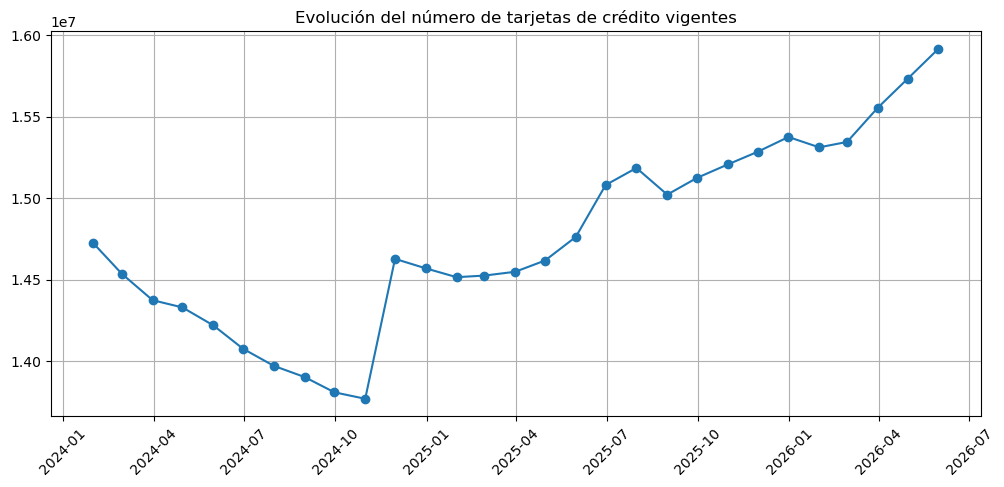

In [129]:
plt.figure(figsize=(12,5))

plt.plot(
    mercado["FECHACORTE"],
    mercado["total_tarjetas"],
    marker="o"
)

plt.title("Evolución del número de tarjetas de crédito vigentes")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

#### Hallazgo:
El número de tarjetas de crédito vigentes presenta una tendencia creciente durante el periodo analizado, esto apesar que tuvo una caida en el primer año.

#### Interpretación: 
Esto indica una expansión sostenida de la base de tarjetas en el mercado colombiano, lo que puede reflejar una mayor adopción del producto financiero.

#### Implicación: 
Para una entidad como BBVA, este comportamiento representa una oportunidad para incrementar participación de mercado, aunque será necesario validar si este crecimiento también se traduce en un mayor uso de las tarjetas y en una cartera saludable.

### Analisis de tarjetas canceladas

Pregunta de negocio:
¿Cómo ha evolucionado el número de tarjetas de crédito canceladas en el mercado colombiano?

---

In [130]:
tarjetas_canceladas = df[
    df["DESCRIPCION"] == "NÚMERO-TOTAL-DE-TARJETAS-DE-CRÉDITO-CANCELADAS"
].copy()

tarjetas_canceladas.head()

,TIPOENTIDAD,CODIGOENTIDAD,NOMBREENTIDAD,FECHACORTE,COD_UCA,NOMBRE_UCA,SUBCUENTA,DESCRIPCION,PERSONA_NATURAL,PERSONA_JURIDICA,TOTAL_TARJETAS,AÑO,MES,MES_NOMBRE,DIA
2,1,1,BANCO-DE-BOGOTA-S-A,2024-01-31,1,CREDIBANCOVISA,15,NÚMERO-TOTAL-DE-TARJETAS-DE-CRÉDITO-CANCELADAS,33534.0,635.0,34169.0,2024,1,enero,31
24,1,1,BANCO-DE-BOGOTA-S-A,2024-01-31,2,MASTERCARD,15,NÚMERO-TOTAL-DE-TARJETAS-DE-CRÉDITO-CANCELADAS,8549.0,32.0,8581.0,2024,1,enero,31
46,1,1,BANCO-DE-BOGOTA-S-A,2024-01-31,5,OTRAS-TARJETAS-DE-CREDITO,15,NÚMERO-TOTAL-DE-TARJETAS-DE-CRÉDITO-CANCELADAS,5.0,0.0,5.0,2024,1,enero,31
71,1,2,BANCO-POPULAR-SA,2024-01-31,1,CREDIBANCOVISA,15,NÚMERO-TOTAL-DE-TARJETAS-DE-CRÉDITO-CANCELADAS,5075.0,17.0,5092.0,2024,1,enero,31
91,1,2,BANCO-POPULAR-SA,2024-01-31,2,MASTERCARD,15,NÚMERO-TOTAL-DE-TARJETAS-DE-CRÉDITO-CANCELADAS,2688.0,0.0,2688.0,2024,1,enero,31


In [131]:
canceladas = (
    tarjetas_canceladas
    .groupby("FECHACORTE", as_index=False)
    .agg(
        total_canceladas=("TOTAL_TARJETAS", "sum")
    )
)

canceladas.head()

,FECHACORTE,total_canceladas
0,2024-01-31,314544.0
1,2024-02-29,284672.0
2,2024-03-31,298427.0
3,2024-04-30,434313.0
4,2024-05-31,306310.0


In [132]:
canceladas["crecimiento_%"] = (
    canceladas["total_canceladas"]
    .pct_change()
    .mul(100)
)
canceladas.tail()

,FECHACORTE,total_canceladas,crecimiento_%
24,2026-01-31,294547.0,-10.307919
25,2026-02-28,262164.0,-10.994171
26,2026-03-31,270040.0,3.004226
27,2026-04-30,250567.0,-7.211154
28,2026-05-31,238699.0,-4.736458


In [133]:
canceladas.describe()

,FECHACORTE,total_canceladas,crecimiento_%
count,29,29.000000,28.000000
mean,2025-03-31 09:06:12.413793024,292247.103448,0.567481
min,2024-01-31 00:00:00,238699.000000,-33.404533
25%,2024-08-31 00:00:00,265138.000000,-10.479482
50%,2025-03-31 00:00:00,285763.000000,0.368234
75%,2025-10-31 00:00:00,304543.000000,6.712463
max,2026-05-31 00:00:00,434313.000000,45.534084
std,NaN,42705.410302,18.339189


In [134]:
canceladas.sort_values("crecimiento_%")

,FECHACORTE,total_canceladas,crecimiento_%
11,2024-12-31,267193.0,-33.404533
4,2024-05-31,306310.0,-29.472523
22,2025-11-30,246715.0,-17.405962
8,2024-09-30,280279.0,-15.173645
15,2025-04-30,257406.0,-14.586064
17,2025-06-30,255741.0,-12.286195
25,2026-02-28,262164.0,-10.994171
24,2026-01-31,294547.0,-10.307919
1,2024-02-29,284672.0,-9.496923
19,2025-08-31,247369.0,-9.290625


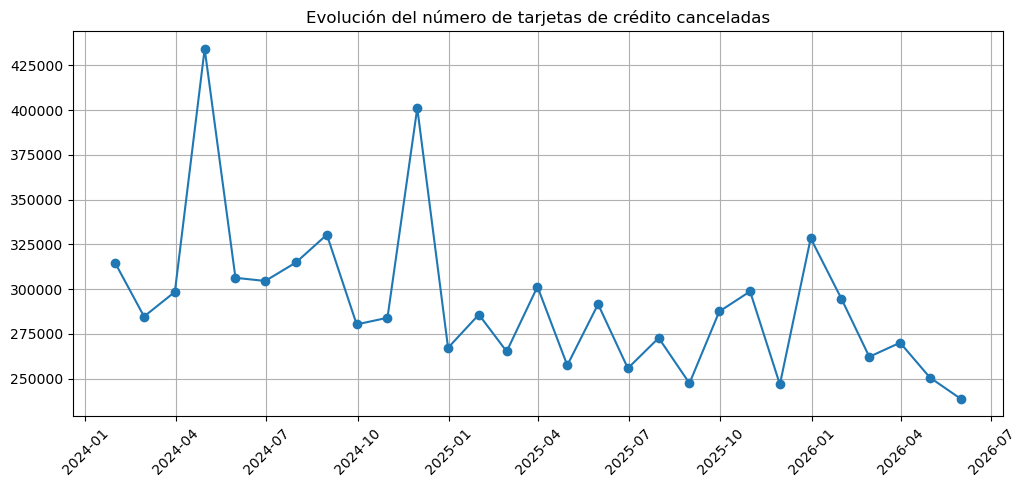

In [135]:
plt.figure(figsize=(12,5))

plt.plot(
    canceladas["FECHACORTE"],
    canceladas["total_canceladas"],
    marker="o"
)

plt.title("Evolución del número de tarjetas de crédito canceladas")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [136]:
cancelaciones_vs_vigentes = mercado.merge(
    canceladas,
    on="FECHACORTE",
    how="inner"
)

In [137]:
cancelaciones_vs_vigentes["tasa_cancelacion_%"] = (
    cancelaciones_vs_vigentes["total_canceladas"] /
    cancelaciones_vs_vigentes["total_tarjetas"]
) * 100

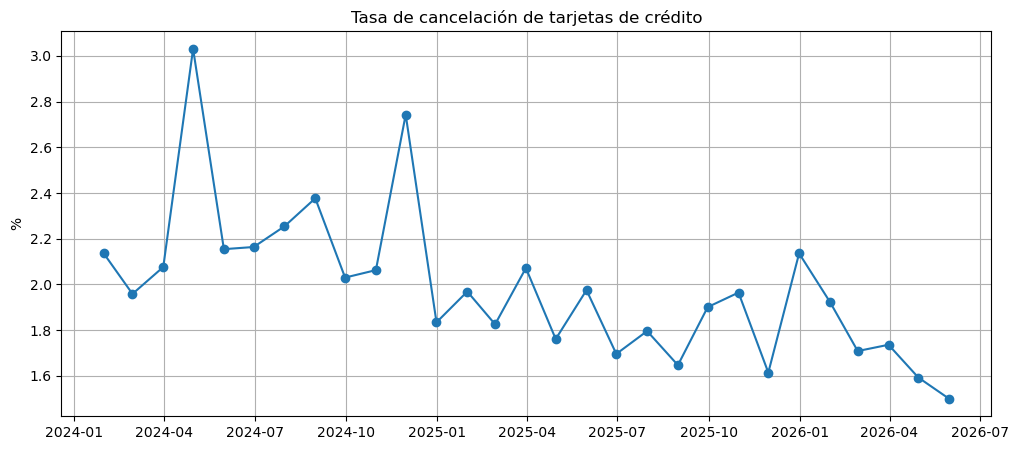

In [138]:
plt.figure(figsize=(12,5))

plt.plot(
    cancelaciones_vs_vigentes["FECHACORTE"],
    cancelaciones_vs_vigentes["tasa_cancelacion_%"],
    marker="o"
)

plt.title("Tasa de cancelación de tarjetas de crédito")

plt.ylabel("%")

plt.grid(True)

plt.show()

#### Hallazgo:
El número de tarjetas canceladas presenta una tendencia decreciente durante el período analizado.

#### Interpretación:
Al comparar las cancelaciones con el total de tarjetas vigentes mediante la tasa de cancelación, se observa que disminuye, lo que indica que el crecimiento del mercado no está acompañado por una mayor pérdida de tarjetas.

#### Implicación para el negocio:
Si la tasa se mantiene estable o disminuye mientras el mercado crece, el comportamiento es consistente con una expansión saludable de la base de tarjetas.

### Analisis de compras

¿Las tarjetas realmente están siendo utilizadas por los clientes?

---

#### Analisis para numero de compras

In [139]:
numero_compras = df[
    df["DESCRIPCION"] ==
    "NÚMERO-DE-TRANSACCIONES-POR-COMPRAS-A-NIVEL-NACIONAL-CON-TARJETA-DE-CRÉDITO"
].copy()

In [140]:
compras = (
    numero_compras
    .groupby("FECHACORTE", as_index=False)
    .agg(
        total_compras=("TOTAL_TARJETAS", "sum")
    )
)

#### Analisis para monto de compras

In [141]:
monto_compras = df[
    df["DESCRIPCION"] ==
    "MONTO-DE-LAS-TRANSACCIONES-POR-COMPRAS-CON-TARJETA-DE-CRÉDITO-A-NIVEL-NACIONAL"
].copy()

In [142]:
monto = (
    monto_compras
    .groupby("FECHACORTE", as_index=False)
    .agg(
        monto_total=("TOTAL_TARJETAS", "sum")
    )
)

#### Analisis conjunto

In [143]:
uso = compras.merge(
    monto,
    on="FECHACORTE"
)

In [145]:
uso["ticket_promedio"] = (
    uso["monto_total"] /
    uso["total_compras"]
)

In [146]:
uso = uso.merge(
    mercado,
    on="FECHACORTE"
)

In [147]:
uso["compras_por_tarjeta"] = (
    uso["total_compras"] /
    uso["total_tarjetas"]
)

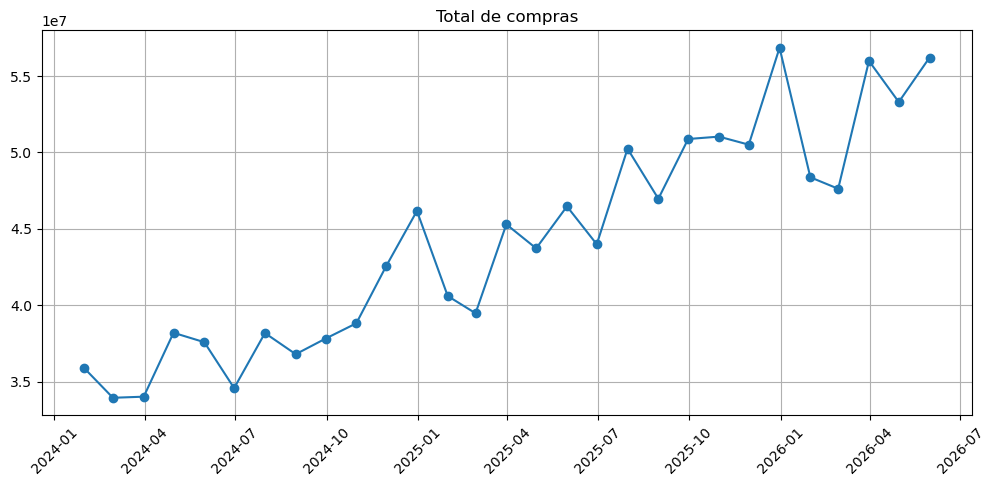

In [161]:
plt.figure(figsize=(12,5))

plt.plot(
    uso["FECHACORTE"],
    uso["total_compras"],
    marker = "o"
)
plt.title("Total de compras")


plt.xticks(rotation=45)

plt.grid(True)

plt.show()

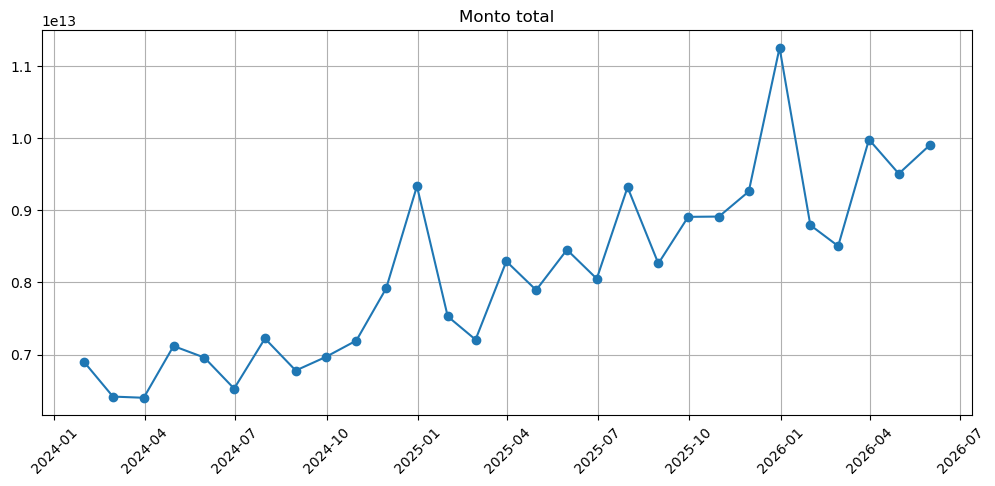

In [164]:
plt.figure(figsize=(12,5))

plt.plot(
    uso["FECHACORTE"],
    uso["monto_total"],
    marker = "o"
)

plt.title("Monto total")


plt.xticks(rotation=45)

plt.grid(True)

plt.show()

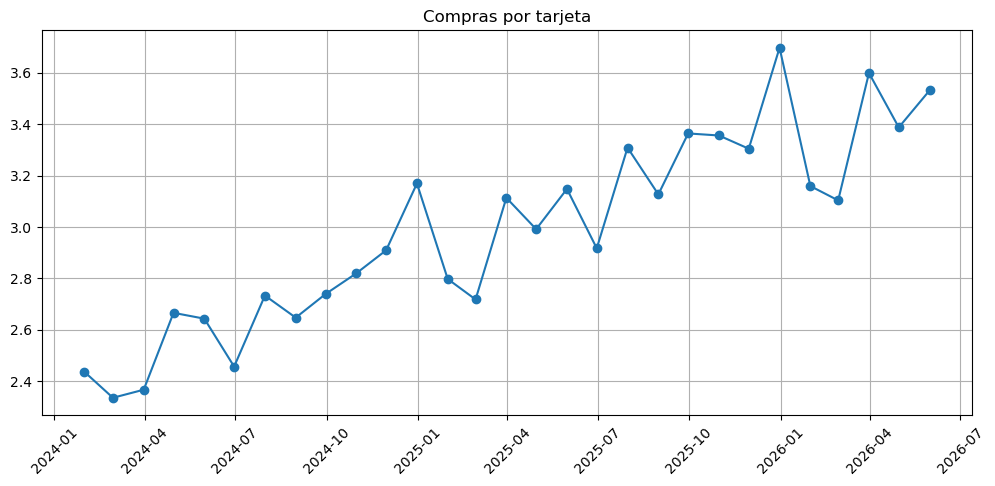

In [168]:
plt.figure(figsize=(12,5))

plt.plot(
    uso["FECHACORTE"],
    uso["compras_por_tarjeta"],
    marker = "o"
)

plt.title("Compras por tarjeta")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

#### Hallazgo:
El saldo total de la cartera presenta una tendencia creciente durante el período analizado.

#### Interpretación:
Al comparar el saldo de cartera con el número de tarjetas vigentes se observa que el saldo promedio por tarjeta también aumenta, lo que indica que el crecimiento del negocio no solo responde a una mayor emisión de tarjetas, sino también a una mayor utilización del crédito por parte de los clientes.

#### Implicación para el negocio:
Este comportamiento puede representar una oportunidad de incremento en ingresos financieros para las entidades. Sin embargo, será importante validar en el siguiente análisis si el aumento del saldo viene acompañado de un crecimiento proporcional en los intereses de mora, ya que esto podría reflejar un mayor nivel de riesgo en la cartera.

### Analisis de saldo de cartera

Pregunta de negocio:
¿El crecimiento del mercado está acompañado por un aumento en el saldo de cartera?

---

In [151]:
saldo_cartera = df[
    df["DESCRIPCION"]=="SALDO-DE-LA-CARTERA-POR-TARJETA-DE-CRÉDITO"
].copy()

saldo_cartera.head()

,TIPOENTIDAD,CODIGOENTIDAD,NOMBREENTIDAD,FECHACORTE,COD_UCA,NOMBRE_UCA,SUBCUENTA,DESCRIPCION,PERSONA_NATURAL,PERSONA_JURIDICA,TOTAL_TARJETAS,AÑO,MES,MES_NOMBRE,DIA
16,1,1,BANCO-DE-BOGOTA-S-A,2024-01-31,1,CREDIBANCOVISA,85,SALDO-DE-LA-CARTERA-POR-TARJETA-DE-CRÉDITO,2.792822e+12,2.225136e+11,3.015335e+12,2024,1,enero,31
38,1,1,BANCO-DE-BOGOTA-S-A,2024-01-31,2,MASTERCARD,85,SALDO-DE-LA-CARTERA-POR-TARJETA-DE-CRÉDITO,8.816643e+11,7.600621e+09,8.892649e+11,2024,1,enero,31
52,1,1,BANCO-DE-BOGOTA-S-A,2024-01-31,5,OTRAS-TARJETAS-DE-CREDITO,85,SALDO-DE-LA-CARTERA-POR-TARJETA-DE-CRÉDITO,7.040653e+07,0.000000e+00,7.040653e+07,2024,1,enero,31
83,1,2,BANCO-POPULAR-SA,2024-01-31,1,CREDIBANCOVISA,85,SALDO-DE-LA-CARTERA-POR-TARJETA-DE-CRÉDITO,3.046140e+11,7.968014e+08,3.054108e+11,2024,1,enero,31
103,1,2,BANCO-POPULAR-SA,2024-01-31,2,MASTERCARD,85,SALDO-DE-LA-CARTERA-POR-TARJETA-DE-CRÉDITO,1.251564e+11,0.000000e+00,1.251564e+11,2024,1,enero,31


In [153]:
saldo = (
    saldo_cartera
    .groupby("FECHACORTE",as_index=False)
    .agg(
        saldo_total=("TOTAL_TARJETAS","sum")
    )
)

saldo.head()

,FECHACORTE,saldo_total
0,2024-01-31,4.108141e+13
1,2024-02-29,4.055293e+13
2,2024-03-31,4.017517e+13
3,2024-04-30,4.031478e+13
4,2024-05-31,3.994349e+13


In [154]:
saldo["crecimiento_%"] = (
    saldo["saldo_total"]
    .pct_change()
    .mul(100)
)

saldo.tail()

,FECHACORTE,saldo_total,crecimiento_%
24,2026-01-31,4.348599e+13,-0.453793
25,2026-02-28,4.354038e+13,0.125087
26,2026-03-31,4.419454e+13,1.502411
27,2026-04-30,4.505229e+13,1.940860
28,2026-05-31,4.597301e+13,2.043656


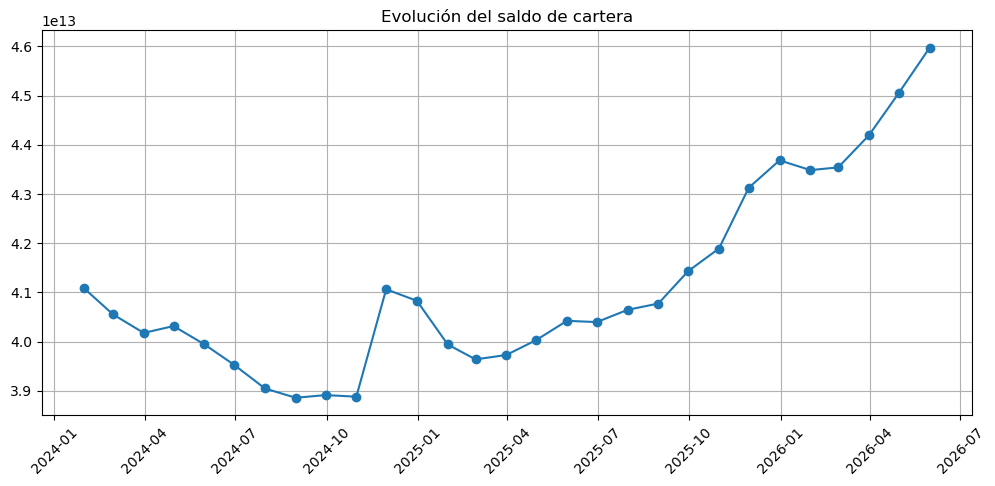

In [155]:
plt.figure(figsize=(12,5))

plt.plot(
    saldo["FECHACORTE"],
    saldo["saldo_total"],
    marker="o"
)

plt.title("Evolución del saldo de cartera")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [156]:
cartera = saldo.merge(
    mercado,
    on="FECHACORTE"
)

In [157]:
cartera["saldo_promedio_por_tarjeta"] = (
    cartera["saldo_total"] /
    cartera["total_tarjetas"]
)

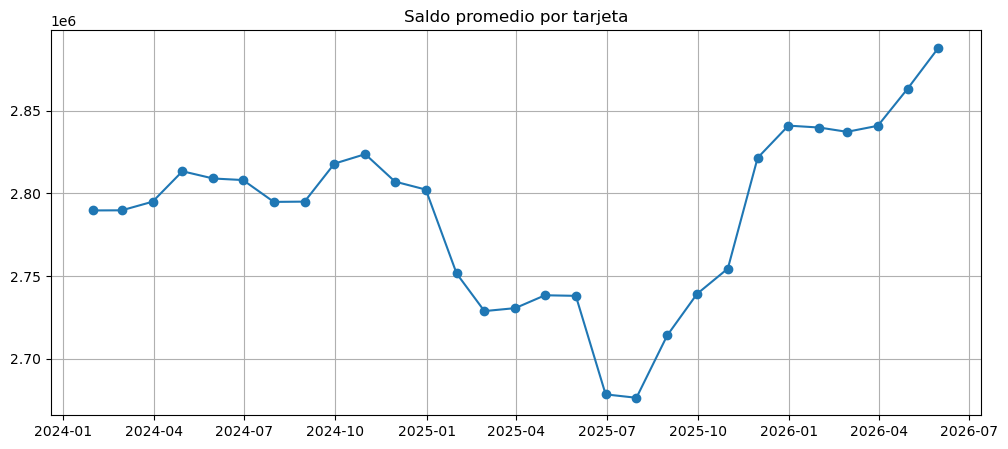

In [158]:
plt.figure(figsize=(12,5))

plt.plot(
    cartera["FECHACORTE"],
    cartera["saldo_promedio_por_tarjeta"],
    marker="o"
)

plt.title("Saldo promedio por tarjeta")

plt.grid(True)

plt.show()

### Rentabilidad y riesgo

Pregunta de negocio:
¿El crecimiento de la cartera se está traduciendo en mayor rentabilidad sin evidenciar un deterioro significativo del riesgo?

---

In [170]:
intereses_corrientes = df[
    df["DESCRIPCION"] ==
    "MONTO-DE-LOS-INTERESES-CORRIENTES-POR-COMPRAS-Y-AVANCES-CON-TARJETA-DE-CRÉDITO"
].copy()

In [171]:
intereses_mora = df[
    df["DESCRIPCION"] ==
    "MONTO-DE-LOS-INTERESES-DE-MORA-POR-COMPRAS-Y-AVANCES-CON-TARJETA-DE-CRÉDITO"
].copy()

In [172]:
corrientes = (
    intereses_corrientes
    .groupby("FECHACORTE", as_index=False)
    .agg(
        intereses_corrientes=("TOTAL_TARJETAS", "sum")
    )
)

In [173]:
mora = (
    intereses_mora
    .groupby("FECHACORTE", as_index=False)
    .agg(
        intereses_mora=("TOTAL_TARJETAS", "sum")
    )
)

In [174]:
intereses = corrientes.merge(
    mora,
    on="FECHACORTE"
)

intereses.head()

,FECHACORTE,intereses_corrientes,intereses_mora
0,2024-01-31,7.592645e+11,4.587682e+10
1,2024-02-29,7.375013e+11,4.322830e+10
2,2024-03-31,7.126273e+11,4.379708e+10
3,2024-04-30,7.022777e+11,4.584430e+10
4,2024-05-31,6.826343e+11,4.178720e+10


In [176]:
intereses["crecimiento_corrientes_%"] = (
    intereses["intereses_corrientes"]
    .pct_change()
    .mul(100)
)

intereses["crecimiento_mora_%"] = (
    intereses["intereses_mora"]
    .pct_change()
    .mul(100)
)

In [177]:
intereses = intereses.merge(
    cartera[["FECHACORTE", "saldo_total"]],
    on="FECHACORTE"
)

In [179]:
intereses["rendimiento_cartera_%"] = (
    intereses["intereses_corrientes"] /
    intereses["saldo_total"]
) * 100

intereses["peso_mora_%"] = (
    intereses["intereses_mora"] /
    intereses["intereses_corrientes"]
) * 100

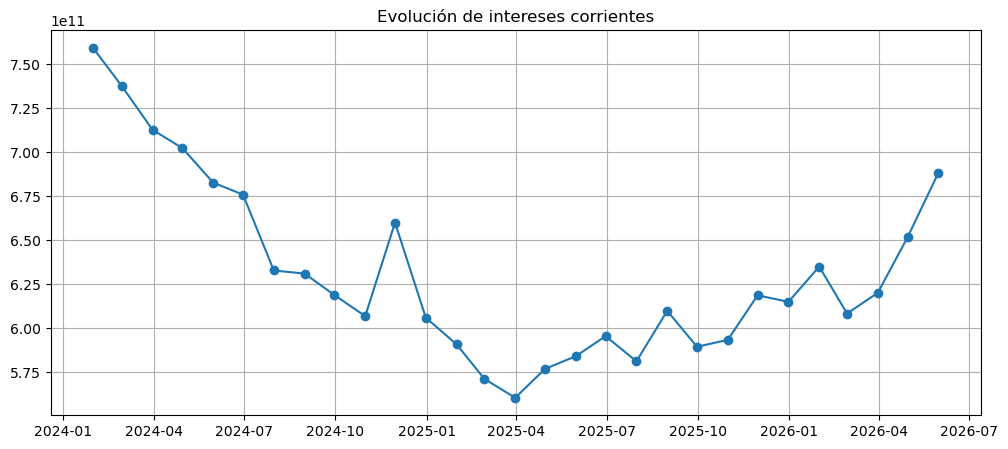

In [180]:
plt.figure(figsize=(12,5))

plt.plot(
    intereses["FECHACORTE"],
    intereses["intereses_corrientes"],
    marker="o"
)

plt.title("Evolución de intereses corrientes")

plt.grid(True)

plt.show()

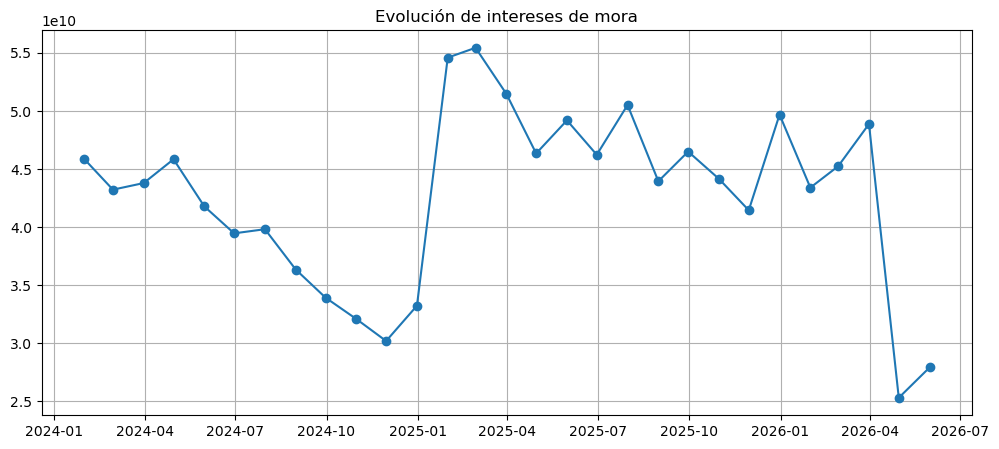

In [181]:
plt.figure(figsize=(12,5))

plt.plot(
    intereses["FECHACORTE"],
    intereses["intereses_mora"],
    marker="o"
)

plt.title("Evolución de intereses de mora")

plt.grid(True)

plt.show()

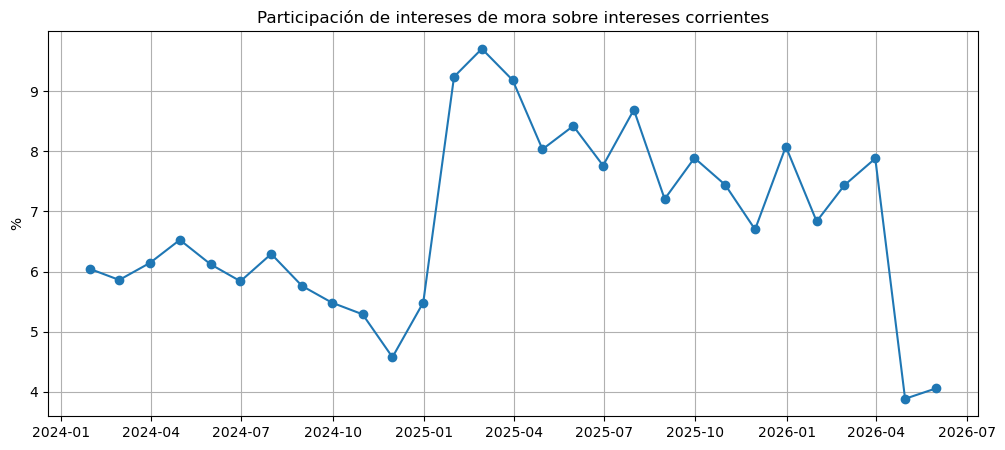

In [182]:
plt.figure(figsize=(12,5))

plt.plot(
    intereses["FECHACORTE"],
    intereses["peso_mora_%"],
    marker="o"
)

plt.title("Participación de intereses de mora sobre intereses corrientes")

plt.ylabel("%")

plt.grid(True)

plt.show()

#### Hallazgo

Los intereses corrientes muestran una tendencia estable, consistente con el incremento observado en el saldo de la cartera.

#### Interpretación

El crecimiento del mercado no solo se refleja en una mayor emisión y utilización de tarjetas, sino también en una mayor generación de ingresos financieros. Al mismo tiempo, la evolución de los intereses de mora y de su participación sobre los intereses corrientes permite evaluar si ese crecimiento mantiene un perfil de riesgo controlado.

#### Implicación para el negocio
El crecimiento de la cartera parece sostenible y rentable.

---

In [178]:
df.sample(2)

,TIPOENTIDAD,CODIGOENTIDAD,NOMBREENTIDAD,FECHACORTE,COD_UCA,NOMBRE_UCA,SUBCUENTA,DESCRIPCION,PERSONA_NATURAL,PERSONA_JURIDICA,TOTAL_TARJETAS,AÑO,MES,MES_NOMBRE,DIA
10427,1,54,BANCO-COOMEVA-SA,2024-08-31,2,MASTERCARD,70,MONTO-DE-LOS-INTERESES-DE-MORA-POR-COMPRAS-Y-AVANCES-CON-TARJETA-DE-CRÉDITO,1.792201e+07,0.0,1.792201e+07,2024,8,agosto,31
2412,1,63,BANCO-SERFINANZA-SA,2024-02-29,5,OTRAS-TARJETAS-DE-CREDITO,90,TOTAL-CUPO-DE-CRÉDITO-NO-UTILIZADO-POR-TODOS-LOS-TARJETAHABIENTES,4.840552e+11,740056328.0,4.847952e+11,2024,2,febrero,29


"Durante el período analizado, el mercado de tarjetas de crédito mostró una expansión sostenida en el número de tarjetas vigentes y en el uso del producto. Este crecimiento estuvo acompañado por un aumento en el saldo de cartera, lo que sugiere una mayor utilización del crédito por parte de los clientes. Finalmente, el comportamiento de los intereses corrientes y de mora permitirá determinar si este crecimiento se está traduciendo en mayor rentabilidad sin evidenciar un deterioro significativo del riesgo."